In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-ai-job-market-and-salary-trends-2025/ai_job_dataset1.csv
/kaggle/input/global-ai-job-market-and-salary-trends-2025/ai_job_dataset.csv


# Import pandas and Numpy

In [2]:
import pandas as pd
import numpy as np

# Load Data

In [3]:
data = pd.read_csv("/kaggle/input/global-ai-job-market-and-salary-trends-2025/ai_job_dataset.csv")
data

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


# Data Exploration & Analysis

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [5]:
data.shape

(15000, 19)

In [6]:
list[data.columns]

list[Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')]

In [7]:
data.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [8]:
data.tail()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


In [9]:
data.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [10]:
data.describe(include="O")

,job_id,job_title,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,required_skills,education_required,industry,posting_date,application_deadline,company_name
count,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000,15000
unique,15000,20,3,4,4,20,3,20,13663,4,15,486,543,16
top,AI00001,Machine Learning Researcher,USD,MI,FT,Germany,S,Sweden,"Python, TensorFlow, PyTorch",Bachelor,Retail,2024-07-05,2025-01-05,TechCorp Inc
freq,1,808,11957,3781,3812,814,5007,790,17,3789,1063,51,47,980


In [11]:
data["job_title"].value_counts().to_frame()

,count
job_title,
Machine Learning Researcher,808
AI Software Engineer,784
Autonomous Systems Engineer,777
Machine Learning Engineer,772
AI Architect,771
Head of AI,765
NLP Engineer,762
Robotics Engineer,759
Data Analyst,759


In [12]:
data["employment_type"].value_counts().to_frame()

,count
employment_type,
FT,3812
FL,3758
CT,3721
PT,3709


In [13]:
data["company_size"].value_counts().to_frame()

,count
company_size,
S,5007
L,4998
M,4995


In [14]:
data["company_name"].value_counts().to_frame()

,count
company_name,
TechCorp Inc,980
Cognitive Computing,972
AI Innovations,964
Digital Transformation LLC,961
Future Systems,960
Quantum Computing Inc,960
Cloud AI Solutions,951
Predictive Systems,947
Smart Analytics,927


In [15]:
data["salary_usd"].unique()

array([ 90376,  61895, 152626, ..., 189490,  79461,  56481])

In [16]:
data["benefits_score"].unique()

array([ 5.9,  5.2,  9.4,  8.6,  6.6,  6.3,  7.6,  9.3,  5.8,  9.9,  6.8,
        9.1,  9.8,  9.6,  8.7,  6.7, 10. ,  6.9,  7.4,  8.8,  7.7,  6. ,
        9.2,  5.3,  5.7,  7.9,  6.1,  8.1,  8. ,  5.1,  7.5,  5.5,  5.4,
        9.7,  7.2,  5.6,  9. ,  6.2,  6.5,  7.1,  9.5,  7. ,  8.2,  8.4,
        7.8,  6.4,  8.3,  8.9,  7.3,  8.5,  5. ])

# Duplicated Entries

In [17]:
data.duplicated().sum()

0

# Handle Missing Values

In [18]:
data.isnull().sum().to_frame()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


# Scaling Data (LOC & ILOC)

In [19]:
data.loc[50:60 ,"salary_usd"].to_frame()

,salary_usd
50,70391
51,115376
52,106579
53,135230
54,67607
55,88470
56,79863
57,60299
58,85645
59,110222


In [20]:
data.iloc[50:60 ,4].to_frame()

,experience_level
50,MI
51,EX
52,MI
53,SE
54,MI
55,MI
56,MI
57,EN
58,MI
59,SE


# Aggregation Functions Of [Columns]

In [21]:
data[["salary_usd"]].agg(["max","mean","min"])

,salary_usd
max,399095.000000
mean,115348.965133
min,32519.000000


In [22]:
data[data["salary_usd"] == 	399095.000000]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
9891,AI09892,Machine Learning Researcher,399095,USD,EX,PT,Switzerland,L,Switzerland,0,"Linux, Python, TensorFlow",Master,10,Retail,2024-07-10,2024-09-02,2277,9.7,TechCorp Inc


In [23]:
data[["benefits_score"]].agg(["max","mean","min"])

,benefits_score
max,10.000000
mean,7.504273
min,5.000000


In [24]:
data[data["benefits_score"] == 5]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
192,AI00193,ML Ops Engineer,134300,USD,EX,CT,Ireland,S,Ireland,50,"Java, Python, Deep Learning, Statistics",Master,11,Education,2024-07-14,2024-09-16,2111,5.0,Predictive Systems
282,AI00283,NLP Engineer,199482,EUR,EX,PT,France,S,France,50,"PyTorch, Scala, NLP, GCP",Bachelor,18,Transportation,2025-02-17,2025-04-30,1230,5.0,TechCorp Inc
332,AI00333,NLP Engineer,44279,USD,EN,CT,Israel,S,Austria,0,"Tableau, Linux, Java, Kubernetes, Computer Vision",PhD,1,Technology,2024-05-02,2024-07-13,539,5.0,Algorithmic Solutions
339,AI00340,Data Scientist,99604,USD,EX,PT,Japan,S,Japan,50,"PyTorch, Mathematics, Linux",Master,11,Education,2024-01-04,2024-02-24,849,5.0,Smart Analytics
510,AI00511,AI Specialist,156725,USD,EX,CT,South Korea,L,Sweden,0,"AWS, Kubernetes, NLP",Associate,19,Media,2024-07-13,2024-09-02,1293,5.0,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14690,AI14691,Autonomous Systems Engineer,157067,USD,SE,FT,Norway,S,Norway,50,"Spark, TensorFlow, Python, Data Visualization",Master,9,Finance,2024-11-15,2024-12-13,1546,5.0,Autonomous Tech
14711,AI14712,Data Scientist,79555,USD,EN,FT,Singapore,L,Netherlands,0,"Python, NLP, Azure, Computer Vision",Master,1,Manufacturing,2025-03-03,2025-04-12,717,5.0,Digital Transformation LLC
14724,AI14725,NLP Engineer,59192,USD,EN,CT,Ireland,L,Ireland,100,"MLOps, Data Visualization, R",PhD,1,Transportation,2024-08-30,2024-10-24,1897,5.0,Digital Transformation LLC
14828,AI14829,Data Analyst,39506,USD,EN,FL,Israel,S,France,0,"Linux, Docker, TensorFlow",Associate,1,Gaming,2024-04-20,2024-05-27,2444,5.0,Cloud AI Solutions


In [25]:
data[["job_description_length"]].agg(["max","mean","min"])

,job_description_length
max,2499.000000
mean,1503.314733
min,500.000000


In [26]:
data[data["job_description_length"] == 2499]

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
1123,AI01124,Head of AI,83896,USD,SE,CT,South Korea,L,South Korea,100,"Data Visualization, Docker, MLOps, Git",Associate,9,Manufacturing,2024-08-19,2024-09-14,2499,5.9,Predictive Systems
2054,AI02055,Machine Learning Researcher,230705,USD,EX,CT,Canada,M,Canada,100,"Linux, Mathematics, Python, Git, Statistics",Associate,11,Automotive,2024-01-21,2024-03-09,2499,5.8,Cloud AI Solutions
2782,AI02783,Autonomous Systems Engineer,51501,USD,EN,FT,Australia,M,Australia,100,"Computer Vision, TensorFlow, Mathematics, SQL,...",PhD,1,Energy,2025-03-22,2025-05-10,2499,8.6,Cloud AI Solutions
3331,AI03332,AI Product Manager,114659,EUR,MI,PT,France,L,France,0,"R, Scala, Git, GCP, Tableau",Master,3,Telecommunications,2024-07-08,2024-07-29,2499,7.2,Cloud AI Solutions
3386,AI03387,AI Consultant,96345,USD,SE,CT,Japan,L,Singapore,50,"R, NLP, Python",Bachelor,6,Real Estate,2024-11-02,2024-11-19,2499,5.3,Algorithmic Solutions
7089,AI07090,Head of AI,63549,EUR,EN,FT,Germany,M,Germany,50,"Git, R, TensorFlow",Bachelor,1,Education,2024-11-25,2025-02-03,2499,9.9,AI Innovations
12736,AI12737,Principal Data Scientist,68443,USD,EN,CT,Switzerland,S,Finland,50,"Mathematics, Java, Hadoop",Bachelor,1,Gaming,2024-04-23,2024-05-28,2499,6.1,Machine Intelligence Group


# Relations

In [27]:
data.groupby("employee_residence")["company_location"].size().to_frame().reset_index()

,employee_residence,company_location
0,Australia,730
1,Austria,776
2,Canada,762
3,China,761
4,Denmark,777
5,Finland,710
6,France,781
7,Germany,769
8,India,772
9,Ireland,740


In [28]:
company_size_analysis = data.groupby(['employee_residence', 'company_location', 'company_size']).agg({
    'job_id': 'count',
    'salary_usd': 'mean'
}).reset_index()
company_size_analysis

,employee_residence,company_location,company_size,job_id,salary_usd
0,Australia,Australia,L,174,139881.344828
1,Australia,Australia,M,177,114206.649718
2,Australia,Australia,S,177,103915.689266
3,Australia,Austria,L,5,124024.600000
4,Australia,Austria,M,3,62957.333333
...,...,...,...,...,...
1171,United States,United Kingdom,M,1,113568.000000
1172,United States,United Kingdom,S,3,135871.333333
1173,United States,United States,L,175,161007.462857
1174,United States,United States,M,169,144004.781065


In [29]:
salary_employment_type = data.groupby(["education_required","employment_type","years_experience"]).agg({
    "job_id": "count",
    "salary_usd": "max"
}).reset_index()

salary_employment_type

,education_required,employment_type,years_experience,job_id,salary_usd
0,Associate,CT,0,113,124467
1,Associate,CT,1,129,116790
2,Associate,CT,2,91,156540
3,Associate,CT,3,63,173822
4,Associate,CT,4,86,162750
...,...,...,...,...,...
315,PhD,PT,15,26,316492
316,PhD,PT,16,22,304214
317,PhD,PT,17,23,344427
318,PhD,PT,18,18,309048


In [30]:
data.groupby("experience_level") ["salary_usd"].max().to_frame().sort_values( by = "salary_usd" , ascending = False )


,salary_usd
experience_level,
EX,399095
SE,247271
MI,177470
EN,131006


In [31]:
data.groupby("job_title") ["salary_usd"].max().to_frame().sort_values( by = "salary_usd" , ascending = False )

,salary_usd
job_title,
Machine Learning Researcher,399095
AI Architect,398084
AI Research Scientist,394917
AI Specialist,390292
Data Scientist,388754
AI Product Manager,381575
AI Software Engineer,379418
Computer Vision Engineer,366957
Principal Data Scientist,364635


In [32]:
data.groupby("company_name") ["salary_usd"].max().to_frame().sort_values( by = "salary_usd" , ascending = False )

,salary_usd
company_name,
TechCorp Inc,399095
Future Systems,398084
Machine Intelligence Group,394917
DataVision Ltd,390292
DeepTech Ventures,388754
Neural Networks Co,381575
Algorithmic Solutions,379418
Quantum Computing Inc,372206
Digital Transformation LLC,364635


In [33]:
data.groupby("posting_date")["application_deadline"].max().to_frame().reset_index()

,posting_date,application_deadline
0,2024-01-01,2024-03-13
1,2024-01-02,2024-03-14
2,2024-01-03,2024-03-14
3,2024-01-04,2024-03-17
4,2024-01-05,2024-03-18
...,...,...
481,2025-04-26,2025-07-08
482,2025-04-27,2025-07-09
483,2025-04-28,2025-07-10
484,2025-04-29,2025-07-09


# Data Visualization

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [35]:
data

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics


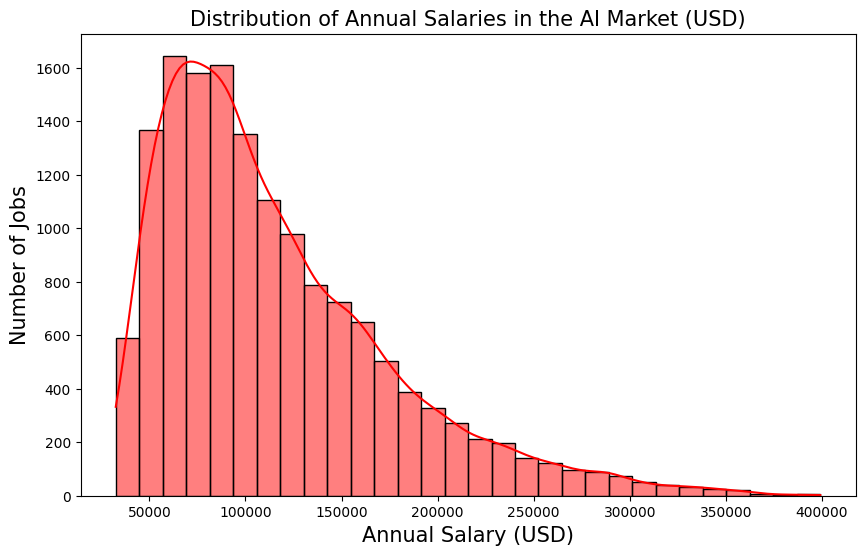

In [36]:
plt.figure(figsize=(10, 6))
sns.histplot(data['salary_usd'], bins=30, kde=True, color='Red')
plt.title('Distribution of Annual Salaries in the AI Market (USD)', fontsize=15)
plt.xlabel('Annual Salary (USD)', fontsize=15)
plt.ylabel('Number of Jobs', fontsize=15)
plt.show()

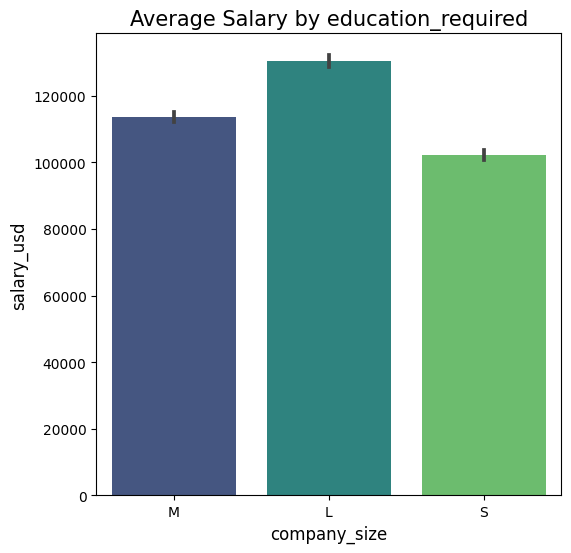

In [37]:
company_size =["S","M","L"]

plt.figure(figsize=(6,6))
company_size =["S","M","L"]
sns.barplot(data=data,x="company_size" ,y="salary_usd" ,palette="viridis")
plt.title("Average Salary by education_required" ,fontsize=15)
plt.xlabel("company_size" ,fontsize=12)
plt.ylabel("salary_usd" ,fontsize=12)
plt.show()

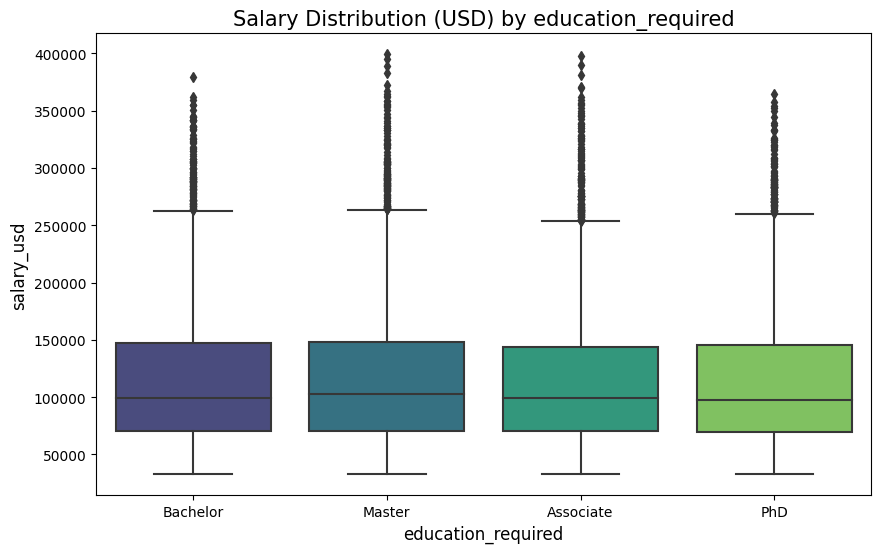

In [38]:
education_required =["Bachelor","Master","Associate","PhD"]

plt.figure(figsize=(10,6))
education_required =["Bachelor","Master","Associate","PhD"]
sns.boxplot(data=data,x="education_required" ,y="salary_usd" ,palette="viridis")
plt.title("Salary Distribution (USD) by education_required" ,fontsize=15)
plt.xlabel("education_required" ,fontsize=12)
plt.ylabel("salary_usd" ,fontsize=12)
plt.show()

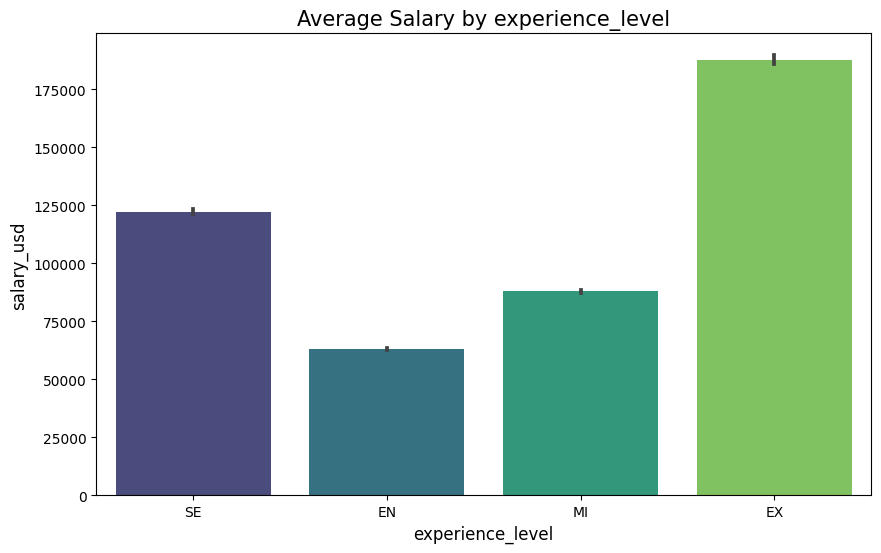

In [39]:
experience_level=["EN","MI","SE","EX"]

plt.figure(figsize=(10,6))
experience_level=["EN","MI","SE","EX"]
sns.barplot(data=data ,x="experience_level" ,y="salary_usd" ,palette="viridis")
plt.title("Average Salary by experience_level" ,fontsize=15)
plt.xlabel("experience_level" ,fontsize=12)
plt.ylabel("salary_usd" ,fontsize=12)
plt.show()


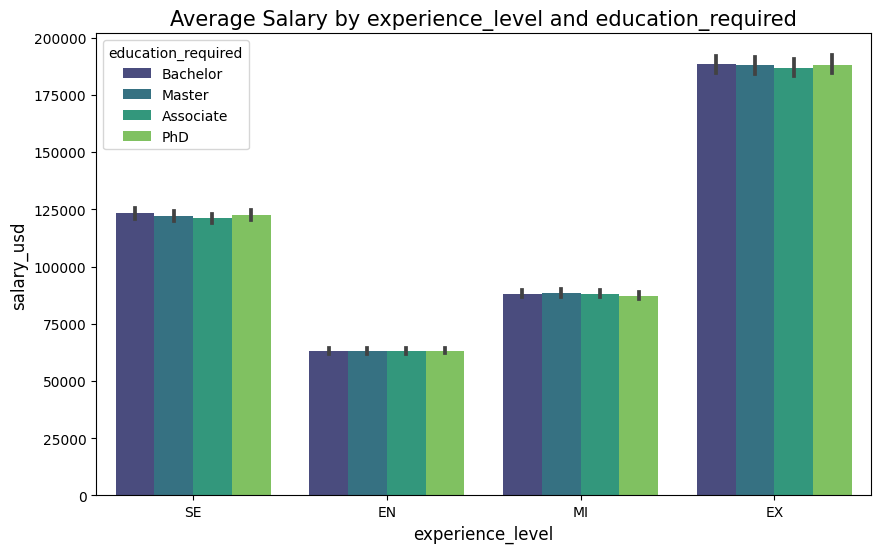

In [40]:
experience_level=["EN","MI","SE","EX"]

plt.figure(figsize=(10,6))
experience_level=["EN","MI","SE","EX"]
sns.barplot(data=data ,x="experience_level" ,y="salary_usd" ,hue="education_required" ,palette="viridis")
plt.title("Average Salary by experience_level and education_required" ,fontsize=15)
plt.xlabel("experience_level" ,fontsize=12)
plt.ylabel("salary_usd" ,fontsize=12)
plt.legend(title="education_required")
plt.show()


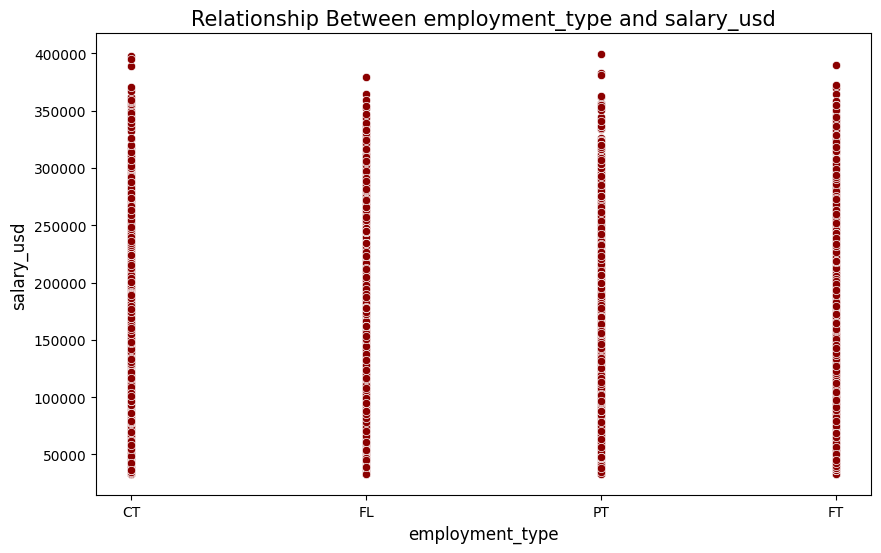

In [41]:
plt.figure(figsize=(10,6))
sns.scatterplot(data =data ,x="employment_type" ,y="salary_usd" ,color="darkred")
plt.title("Relationship Between employment_type and salary_usd" ,fontsize=15)
plt.xlabel("employment_type" ,fontsize=12)
plt.ylabel("salary_usd" ,fontsize=12)
plt.show()

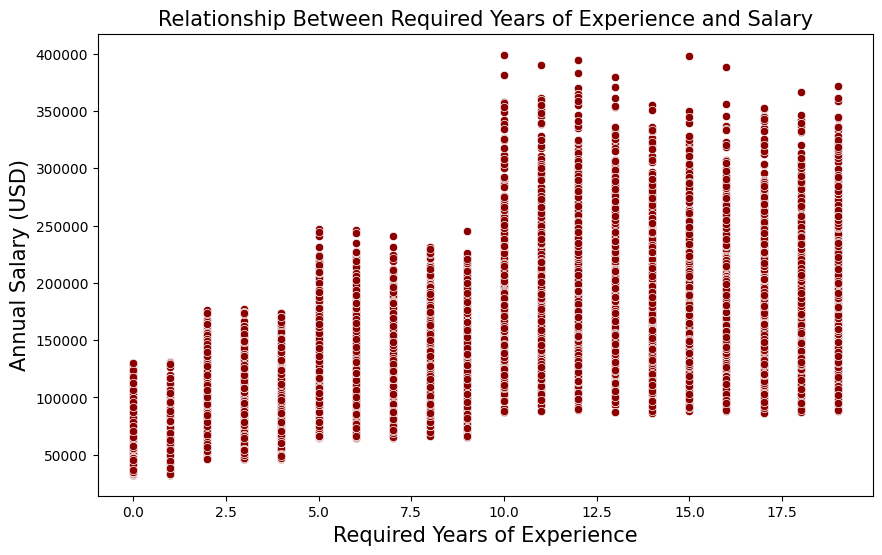

In [42]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='years_experience', y='salary_usd', data=data,color='darkred')
plt.title('Relationship Between Required Years of Experience and Salary', fontsize=15)
plt.xlabel('Required Years of Experience', fontsize=15)
plt.ylabel('Annual Salary (USD)', fontsize=15)
plt.show()